In [1]:
import pandas as pd
import numpy as np

attack = pd.read_csv("attack_samples_10sec.csv")
benign = pd.read_csv("benign_samples_10sec.csv")

attack["label"] = 1
benign["label"] = 0

df = pd.concat([attack, benign], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
df.head()

(30030, 95)


,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,...,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation,label
0,vibration-sensor,08:b6:1f:82:27:d0,attack_recon_ping-sweep_whole-network,attack,recon,ping-sweep,recon_ping-sweep,2025-01-15T13:11:14.297000Z_2025-01-15T13:11:2...,2025-01-15T13:11:14.297000Z,2025-01-15T13:11:24.297000Z,...,0.013532,159.50,255.0,64.0,95.500000,34448.500000,64075.0,4822.0,29626.500000,1
1,plug-all-cameras,c4:dd:57:15:5c:2c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:29:20.400000Z_2025-09-09T14:29:3...,2025-09-09T14:29:20.400000Z,2025-09-09T14:29:30.400000Z,...,0.010389,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000,0
2,vibration-sensor,08:b6:1f:82:27:d0,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:16:30.400000Z_2025-09-09T14:16:4...,2025-09-09T14:16:30.400000Z,2025-09-09T14:16:40.400000Z,...,0.025374,159.50,255.0,64.0,95.500000,34855.500000,64075.0,5636.0,29219.500000,0
3,gas-sensor,08:b6:1f:83:25:98,attack_dos_ack-frag-flood-port-1883_gas-sensor,attack,dos,ack-frag-flood-port-1883,dos_ack-frag-flood-port-1883,2025-01-20T17:38:28.067000Z_2025-01-20T17:38:3...,2025-01-20T17:38:28.067000Z,2025-01-20T17:38:38.067000Z,...,0.000147,64.00,64.0,64.0,0.000000,512.000000,512.0,512.0,0.000000,1
4,plug-all-sensors,d4:a6:51:82:98:a8,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:40:10.400000Z_2025-09-09T14:40:2...,2025-09-09T14:40:10.400000Z,2025-09-09T14:40:20.400000Z,...,0.028604,250.75,255.0,238.0,7.361216,22848.666667,65535.0,1471.0,30183.808908,0


In [2]:
selected_features = [
    "network_packet-size_avg",
    "network_packet-size_std_deviation",
    "network_payload-length_avg",
    "network_time-delta_avg",
    "network_ttl_avg",
    "network_header-length_avg"
]

X = df[selected_features].copy()
y = df["label"].astype(int).values

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
class ClassificationEnv:
    def __init__(self, X, y):
        self.X = np.array(X, dtype=np.float32)
        self.y = np.array(y, dtype=np.int64)
        self.n_samples = len(self.y)

    def reset(self):
        self.indices = np.random.permutation(self.n_samples)
        self.current = 0
        return self.X[self.indices[self.current]]

    def step(self, action):
        true_label = self.y[self.indices[self.current]]
        reward = 1 if action == true_label else -1

        self.current += 1
        done = self.current >= self.n_samples

        if done:
            next_state = np.zeros(self.X.shape[1], dtype=np.float32)
        else:
            next_state = self.X[self.indices[self.current]]

        return next_state, reward, done, true_label

In [5]:
!pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.6/530.6 MB 4.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 73.8 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 62.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 6.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 27.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 73.6 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.1/188.1 MB 11.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 KB 19.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 11.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 10.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class DQN(nn.Module):
    def __init__(self, input_dim, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = map(np.array, zip(*batch))
        return s, a, r, ns, d

    def __len__(self):
        return len(self.buffer)

In [8]:
env = ClassificationEnv(X_train, y_train)

policy_net = DQN(input_dim=X_train.shape[1]).to(device)
target_net = DQN(input_dim=X_train.shape[1]).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
buffer = ReplayBuffer()

gamma = 0.95
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
batch_size = 64
episodes = 20
target_update = 5

reward_history = []

for ep in range(episodes):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        if random.random() < epsilon:
            action = random.randint(0, 1)
        else:
            with torch.no_grad():
                s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                action = int(torch.argmax(policy_net(s), dim=1).item())

        next_state, reward, done, true_label = env.step(action)
        buffer.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

        if len(buffer) >= batch_size:
            s, a, r, ns, d = buffer.sample(batch_size)

            s = torch.tensor(s, dtype=torch.float32, device=device)
            a = torch.tensor(a, dtype=torch.int64, device=device).unsqueeze(1)
            r = torch.tensor(r, dtype=torch.float32, device=device)
            ns = torch.tensor(ns, dtype=torch.float32, device=device)
            d = torch.tensor(d, dtype=torch.float32, device=device)

            q_values = policy_net(s).gather(1, a).squeeze(1)
            with torch.no_grad():
                next_q = target_net(ns).max(1)[0]
                target = r + gamma * (1 - d) * next_q

            loss = loss_fn(q_values, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    reward_history.append(total_reward)

    if (ep + 1) % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    print(f"Episode {ep+1}: reward = {total_reward}, epsilon = {epsilon:.3f}")

Episode 1: reward = 126, epsilon = 0.995
Episode 2: reward = 354, epsilon = 0.990
Episode 3: reward = 110, epsilon = 0.985
Episode 4: reward = 82, epsilon = 0.980
Episode 5: reward = 450, epsilon = 0.975
Episode 6: reward = 752, epsilon = 0.970
Episode 7: reward = 788, epsilon = 0.966
Episode 8: reward = 732, epsilon = 0.961
Episode 9: reward = 820, epsilon = 0.956
Episode 10: reward = 1254, epsilon = 0.951
Episode 11: reward = 1034, epsilon = 0.946
Episode 12: reward = 1122, epsilon = 0.942
Episode 13: reward = 1476, epsilon = 0.937
Episode 14: reward = 1728, epsilon = 0.932
Episode 15: reward = 1604, epsilon = 0.928
Episode 16: reward = 1960, epsilon = 0.923
Episode 17: reward = 1772, epsilon = 0.918
Episode 18: reward = 1888, epsilon = 0.914
Episode 19: reward = 2262, epsilon = 0.909
Episode 20: reward = 1920, epsilon = 0.905


In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, accuracy_score, confusion_matrix

test_env = ClassificationEnv(X_test, y_test)

y_true = []
y_pred = []

state = test_env.reset()
done = False

while not done:
    with torch.no_grad():
        s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        action = int(torch.argmax(policy_net(s), dim=1).item())

    next_state, reward, done, true_label = test_env.step(action)
    y_true.append(true_label)
    y_pred.append(action)
    state = next_state

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1-score:", f1_score(y_true, y_pred))
print("MCC:", matthews_corrcoef(y_true, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

Accuracy: 0.9695304695304695
Precision: 0.9898444938114884
Recall: 0.9538226299694189
F1-score: 0.9714997663915278
MCC: 0.9395372163197325
Confusion matrix:
 [[2704   32]
 [ 151 3119]]


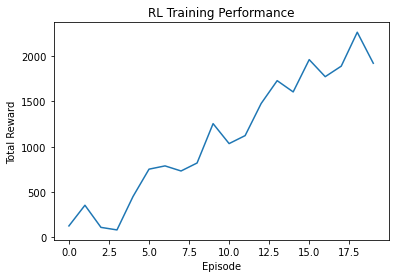

In [10]:
import matplotlib.pyplot as plt

plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("RL Training Performance")
plt.show()